In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


In [ ]:
df = pd.read_csv("C:\\Users\\vijay\\OneDrive\\Documents\\Diabetes_Prediction\\Part_1\\cleaned_data.csv")
print(df.head(5))

   NoOfPregency  PlasmaGlucoseCon  BloodPressure  SkinFoldThickness  Insuline  \
0          10.0             108.0           66.0               29.0     130.0   
1           7.0             107.0           74.0               29.0     130.0   
2           0.0             179.0           90.0               27.0     130.0   
3          10.0             125.0           70.0               26.0     130.0   
4          10.0             117.0           72.0               29.0     130.0   

    BMI  DiabetesPedigree   Age            Class  
0  32.4             0.272  42.0  tested_positive  
1  29.6             0.254  31.0  tested_positive  
2  32.0             0.686  23.0  tested_positive  
3  31.1             0.205  41.0  tested_positive  
4  38.0             0.537  34.0  tested_positive  


In [14]:
df.dtypes

NoOfPregency         float64
PlasmaGlucoseCon     float64
BloodPressure        float64
SkinFoldThickness    float64
Insuline             float64
BMI                  float64
DiabetesPedigree     float64
Age                  float64
Class                 object
dtype: object

In [ ]:
X = df.drop(columns=['Class'])
X.dtypes

NoOfPregency         float64
PlasmaGlucoseCon     float64
BloodPressure        float64
SkinFoldThickness    float64
Insuline             float64
BMI                  float64
DiabetesPedigree     float64
Age                  float64
dtype: object

In [ ]:
y_clf = df["Class"]
y_clf.dtype

dtype('O')

In [ ]:
y_clf = y_clf.map({'tested_negative': 0, 'tested_positive': 1})
print(y_clf.head())
print(y_clf.dtype)

0    1
1    1
2    1
3    1
4    1
Name: Class, dtype: int64
int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y_clf, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)      

In [19]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

Class
0    354
1    198
Name: count, dtype: int64
Class
0    0.641304
1    0.358696
Name: proportion, dtype: float64


In [ ]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[82 14]
 [14 28]]


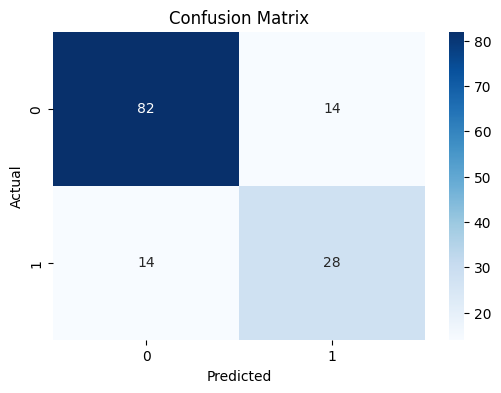

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85        96
           1       0.67      0.67      0.67        42

    accuracy                           0.80       138
   macro avg       0.76      0.76      0.76       138
weighted avg       0.80      0.80      0.80       138



In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)
print("Accuracy :", round(accuracy_score(y_test, y_pred),4))
print("Precision:", round(precision_score(y_test, y_pred),4))
print("Recall   :", round(recall_score(y_test, y_pred),4))
print("F1 Score :", round(f1_score(y_test, y_pred),4))

Accuracy : 0.7971
Precision: 0.6667
Recall   : 0.6667
F1 Score : 0.6667


In [25]:
from sklearn.metrics import ( roc_curve, roc_auc_score)
fpr, tpr, thresholds = roc_curve( y_test, y_prob)
auc_score = round(roc_auc_score(y_test, y_prob),4)
print("AUC:", auc_score)

AUC: 0.8219


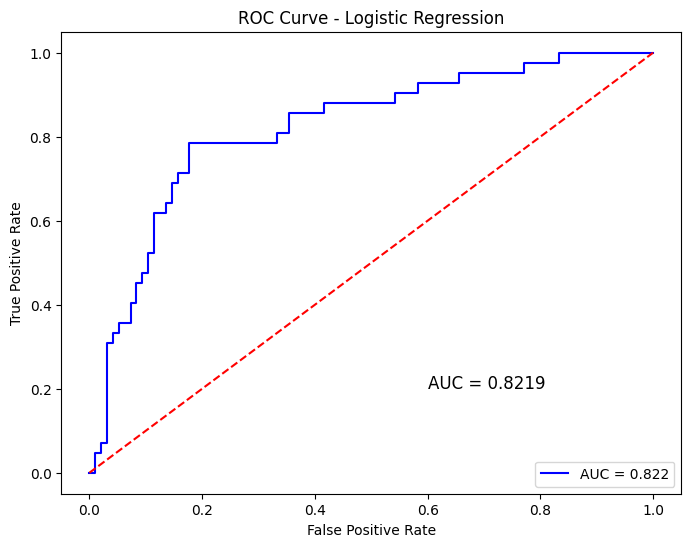

In [26]:
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr, label=f"AUC = {auc_score:.3f}", color="blue")
plt.plot([0,1], [0,1], linestyle="--", color="red")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.text(0.6, 0.2, f"AUC = {auc_score:.4f}", fontsize=12)
plt.savefig('ROC_Curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
results = []
for threshold in thresholds:
    y_pred_thresh = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    results.append([threshold, precision, recall, f1])
results_df = pd.DataFrame(results, columns=["Threshold", "Precision", "Recall", "F1"])
print(results_df.round(3))

   Threshold  Precision  Recall     F1
0        0.3      0.524   0.786  0.629
1        0.4      0.653   0.762  0.703
2        0.5      0.667   0.667  0.667
3        0.6      0.667   0.476  0.556
4        0.7      0.750   0.357  0.484


In [ ]:
log_reg_reg = LogisticRegression(C=0.01, max_iter=1000, random_state=42)
log_reg_reg.fit(X_train_scaled, y_train)
y_pred_reg = log_reg_reg.predict(X_test_scaled)
y_prob_reg = log_reg_reg.predict_proba(X_test_scaled)[:, 1]
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
print("Accuracy :", round(accuracy_score(y_test, y_pred_reg),4))
print("Precision:", round(precision_score(y_test, y_pred_reg),4))
print("Recall   :", round(recall_score(y_test, y_pred_reg),4))
print("F1 Score :", round(f1_score(y_test, y_pred_reg),4))
print("AUC      :", round(roc_auc_score(y_test, y_prob_reg),4))

Accuracy : 0.7754
Precision: 0.6774
Recall   : 0.5
F1 Score : 0.5753
AUC      : 0.8254


In [38]:
coef_comparison = pd.DataFrame({"Feature": X.columns,"Default LR (C=1.0)": log_reg.coef_[0], "Regularized LR (C=0.01)": log_reg_reg.coef_[0]})
print(coef_comparison)

             Feature  Default LR (C=1.0)  Regularized LR (C=0.01)
0       NoOfPregency            0.317548                 0.171431
1   PlasmaGlucoseCon            1.022767                 0.469274
2      BloodPressure           -0.020429                 0.065640
3  SkinFoldThickness            0.192777                 0.141500
4           Insuline            0.065688                 0.109528
5                BMI            0.445130                 0.229440
6   DiabetesPedigree            0.270120                 0.125495
7                Age            0.186581                 0.145209


In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score
np.random.seed(42)
n_bootstrap = 500
auc_differences = []
for _ in range(n_bootstrap):
    idx = np.random.choice(len(y_test), size=len(y_test), replace=True)
    y_boot = y_test.iloc[idx] if hasattr(y_test, "iloc") else y_test[idx]
    auc_c1 = roc_auc_score(y_boot, y_prob[idx])
    auc_c001 = roc_auc_score(y_boot, y_prob_reg[idx])
    auc_differences.append(auc_c1 - auc_c001)
auc_differences = np.array(auc_differences)
mean_diff = auc_differences.mean()
lower_ci = np.percentile(auc_differences, 2.5)
upper_ci = np.percentile(auc_differences, 97.5)
print(f"Mean AUC Difference: {mean_diff:.4f}")
print(f"95% CI: [{lower_ci:.4f}, {upper_ci:.4f}]")

Mean AUC Difference: -0.0035
95% CI: [-0.0162, 0.0090]


In [ ]:
import pandas as pd
results = pd.DataFrame({"Metric": ["Mean AUC Difference", "2.5th Percentile", "97.5th Percentile"], "Value": [mean_diff, lower_ci, upper_ci]})
print(results.round(4))

                Metric   Value
0  Mean AUC Difference -0.0035
1     2.5th Percentile -0.0162
2    97.5th Percentile  0.0090
